In [10]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://happy-research.s3.ap-southeast-1.amazonaws.com/toy-datasets/electric_production.csv")

field_name = "IPG2211A2N"

df

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151
...,...,...
392,9/1/2017,98.6154
393,10/1/2017,93.6137
394,11/1/2017,97.3359
395,12/1/2017,114.7212


In [5]:
class CustomTimeSeriesDataset(Dataset):
    def __init__(self, data, window_length, num_outputs, stride): #constructor, window_length being how many items we use for predictio, num_outputs being how many items do we want to predict
        self.data = data
        self.window_length = window_length
        self.num_outputs = num_outputs
        self.stride = stride
        self.num_samples = (data.shape[0] - window_length - num_outputs) // stride + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        start_idx = idx * self.stride
        x = self.data[start_idx : start_idx + self.window_length]
        y = self.data[start_idx + self.window_length : start_idx + self.window_length + self.num_outputs]
        return x, y

In [9]:
window_length = 10
num_outputs = 3
stride = 1

data_tensor = torch.tensor(df[field_name].values, dtype = torch.float32)
data_tensor
time_series_dataset = CustomTimeSeriesDataset(data_tensor, window_length, num_outputs, stride)

sample_1_x, sample_1_y = time_series_dataset[0]
print(sample_1_x)
print(sample_1_y)

tensor([72.5052, 70.6720, 62.4502, 57.4714, 55.3151, 58.0904, 62.6202, 63.2485,
        60.5846, 56.3154])
tensor([58.0005, 68.7145, 73.3057])


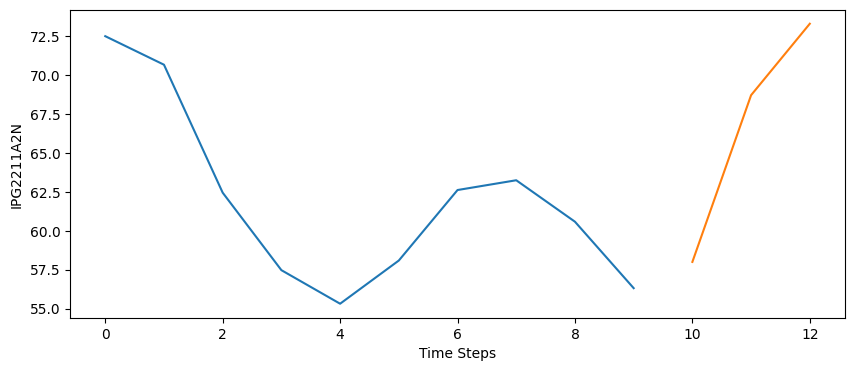

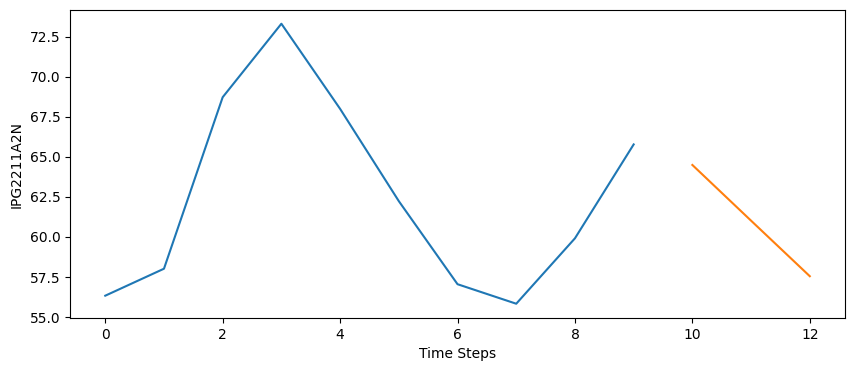

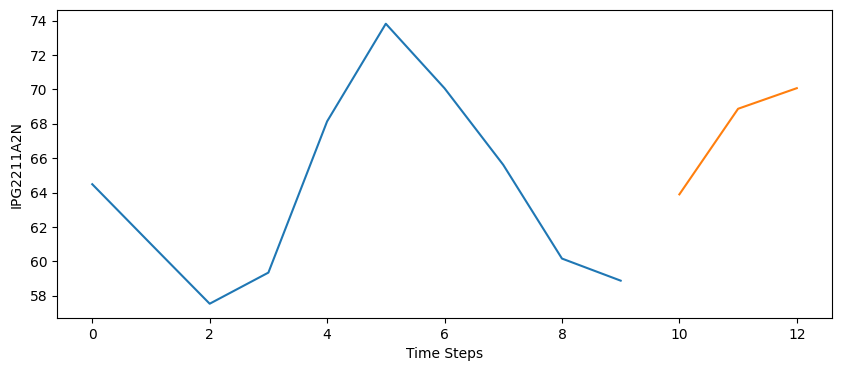

In [15]:
sample_indices = [0, 9, 19]

for idx in sample_indices:
    x, y = time_series_dataset[idx]

    plt.figure(figsize = (10,4))
    plt.plot(range(len(x)), x.cpu().numpy())
    plt.plot(range(len(x), len(x) + len(y)), y.cpu().numpy())
    plt.xlabel("Time Steps")
    plt.ylabel(field_name)
    plt.show()